In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind



In [3]:
trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [30]:
print(trader.head(3))


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  buy  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  buy  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  buy  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp                time  \
0    

In [31]:
print(sentiment.head(3))

         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme fear
2  2018-02-03           Fear


In [34]:
trader['time'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M')

trader['date'] = trader['time'].dt.date

trader = trader.dropna(subset=['Closed PnL', 'Size Tokens', 'Execution Price', 'date'])

trader['Side'] = trader['Side'].str.lower()

In [35]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

sentiment['classification'] = sentiment['classification'].str.capitalize()
sentiment = sentiment[['date', 'classification']]

In [38]:
merged_df = pd.merge(trader, sentiment, on='date', how='inner')

print("Merged Shape:", merged_df.shape)
merged_df.head(3)

Merged Shape: (211218, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed


In [39]:
merged_df['postion_value'] = merged_df['Size Tokens'].abs()*merged_df['Execution Price']

In [40]:
merged_df['is_profitable'] = merged_df['Closed PnL'] > 0

In [42]:
merged_df['pnl_ratio'] = merged_df['Closed PnL'] / merged_df['postion_value']

Merged Shape: (211218, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme greed


In [43]:
merged_df['is_profitable'] = merged_df['Closed PnL'] > 0

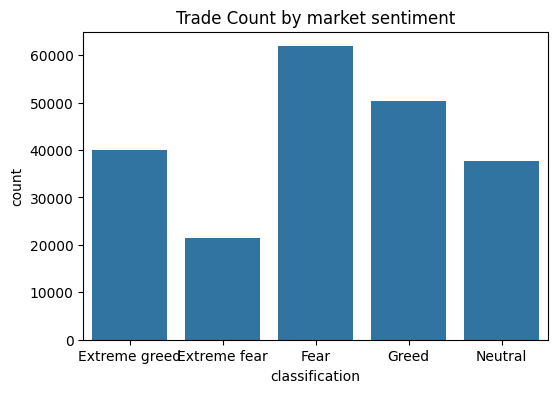

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=merged_df, x='classification')
plt.title('Trade Count by market sentiment')
plt.show()

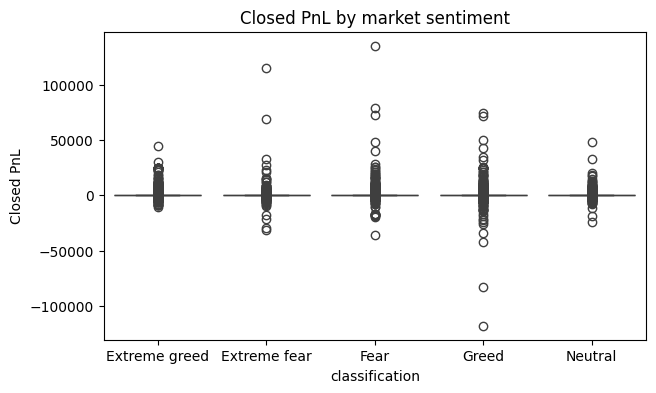

In [45]:
plt.figure(figsize=(7,4))
sns.boxplot(data=merged_df, x='classification',y='Closed PnL')
plt.title("Closed PnL by market sentiment")
plt.show()

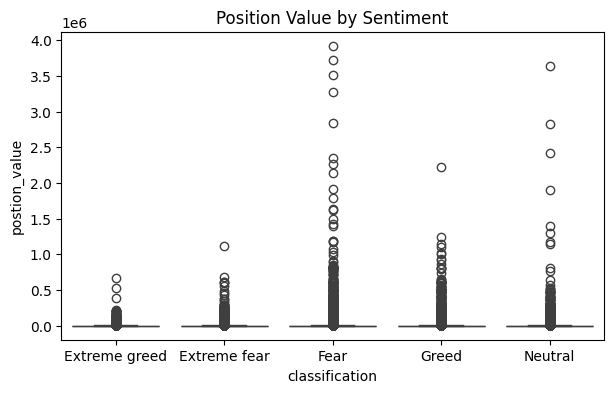

In [47]:
plt.figure(figsize=(7,4))
sns.boxplot(data=merged_df, x='classification', y='postion_value')
plt.title("Position Value by Sentiment")
plt.show()

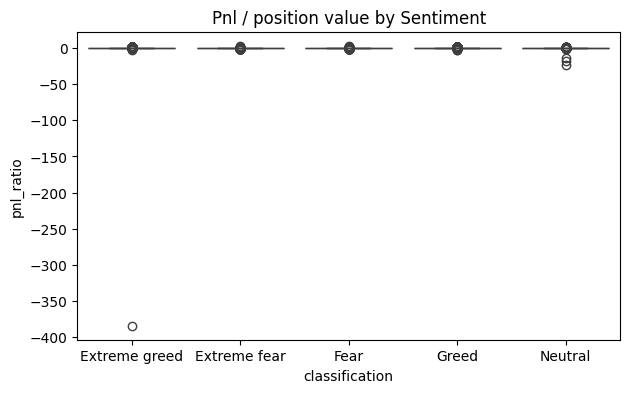

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(data=merged_df, x='classification', y='pnl_ratio')
plt.title("Pnl / position value by Sentiment")
plt.show()

In [49]:
summary = merged_df.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    win_rate=('is_profitable', 'mean'),
    avg_position_value=('postion_value', 'mean'),
    avg_pnl_ratio=('pnl_ratio', 'mean'),
    trade_count=('Closed PnL', 'count')
).reset_index()

summary


,classification,avg_pnl,median_pnl,win_rate,avg_position_value,avg_pnl_ratio,trade_count
0,Extreme fear,34.537862,0.0,0.370607,5349.731778,0.004322,21400
1,Extreme greed,67.892861,0.0,0.464943,3112.251531,0.040014,39992
2,Fear,54.290400,0.0,0.420768,7816.109965,0.015409,61837
3,Greed,42.743559,0.0,0.384828,5736.884385,0.019645,50303
4,Neutral,34.307718,0.0,0.396991,4782.732642,0.009937,37686


In [50]:
fear_pnl = merged_df[merged_df['classification'] == 'Fear']['Closed PnL']
greed_pnl = merged_df[merged_df['classification'] == 'Greed']['Closed PnL']

t_stat, p_value = ttest_ind(fear_pnl, greed_pnl, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant difference in PnL")
else:
    print("No statistically significant difference in PnL")


T-statistic: 1.8511431575014454
P-value: 0.06415196288057486
No statistically significant difference in PnL


In [52]:
trader_summary = merged_df.groupby(['Account', 'classification']).agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_position_value=('postion_value', 'mean'),
    trades=('Closed PnL', 'count')
).reset_index()

trader_summary.head()

,Account,classification,total_pnl,avg_position_value,trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme fear,1.247692e+05,15071.008913,100
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme greed,-4.028234e+04,12080.270431,945
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.113374e+06,17020.494938,1778
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,2.767193e+05,15134.130679,574
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,1.256501e+05,23336.999490,421


In [53]:
consistent_traders = trader_summary[
    (trader_summary['total_pnl'] > 0) &
    (trader_summary['trades'] >= 10)
]

consistent_traders.sort_values('total_pnl', ascending=False).head(10)


,Account,classification,total_pnl,avg_position_value,trades
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.113374e+06,17020.494938,1778
135,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme greed,1.105305e+06,3141.526925,1643
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,6.208724e+05,3275.305013,12437
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,5.340582e+05,6161.486067,5889
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme greed,4.788115e+05,2458.408727,6723
78,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,4.535953e+05,8515.414139,593
138,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Neutral,4.013094e+05,2621.968885,3457
69,0x513b8629fe877bb581bf244e326a047b249c4ff1,Neutral,3.813305e+05,27702.051025,2517
67,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,3.671662e+05,37633.678902,5981
57,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,2.967817e+05,13057.168827,1396


In [54]:

import os
os.makedirs("csv_files", exist_ok=True)


summary.to_csv("csv_files/sentiment_summary.csv", index=False)
merged_df.to_csv("csv_files/merged_trader_sentiment.csv", index=False)
